# Feature Selection in Image Analysis using Genetic Algorithms + SVM

---

## Problem Statement

Modern image analysis pipelines often extract **high-dimensional feature vectors** by combining multiple descriptors. This project uses a dataset with **4844 features** — a combination of:
- **HOG (Histogram of Oriented Gradients):** Captures edge/shape structure by computing gradient orientations in localized image patches.
- **LBP (Local Binary Patterns):** Captures texture information by thresholding pixel neighborhoods.

While combining descriptors improves representational power, it introduces the **curse of dimensionality**:
- Model training time increases dramatically
- Irrelevant/redundant features add noise and hurt generalization
- Memory and inference costs become prohibitive
- Overfitting risk increases, especially with limited data

## Approach

We use a **Genetic Algorithm (GA)** — a population-based metaheuristic inspired by biological evolution — to search the exponentially large feature subset space (2^8110 possible subsets).

Each **individual** in the GA population is a **binary chromosome** of length 8,110:
- `1` = feature selected
- `0` = feature excluded

A **Support Vector Machine (SVM)** acts as the fitness evaluator: a chromosome's quality is measured by the cross-validated accuracy of an SVM trained only on its selected features.

The fitness function balances **accuracy** vs **feature reduction**:

```
fitness = alpha * accuracy + beta * (1 - selected_ratio)
```

where `alpha=0.9` prioritizes accuracy and `beta=0.1` rewards smaller feature subsets.

---

**Goal:** Find a compact feature subset that matches or exceeds baseline SVM performance on all 8,110 features.

In [1]:
# ============================================================
# Cell 1: Import all required libraries and configure globals.
# Sets numpy random seed for full reproducibility.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import time

from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from tqdm import tqdm

# ── Global settings ──────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})
sns.set_style('whitegrid')

# ── Output directory for saved figures ──────────────────────
os.makedirs('figures', exist_ok=True)

print("All imports successful.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
print(f"   Random seed set to: {RANDOM_SEED}")

All imports successful.
   NumPy  : 2.0.2
   Pandas : 2.2.2
   Random seed set to: 42


---
<a id='section2'></a>
## 2. Data Loading & Exploration

In [3]:
# ============================================================
# Cell 2: Load pre-extracted HOG+LBP feature arrays from disk.
# Prints shapes, number of classes, and class distribution.
# ============================================================

X = np.load('XPCA_features_80.npy')
y = np.load('y_labels.npy')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Feature matrix shape  : {X.shape}  (samples , features)")
print(f"Label vector shape    : {y.shape}")
print(f"Total samples         : {X.shape[0]}")
print(f"Total features        : {X.shape[1]}")

# ── Class information ────────────────────────────────────────
unique_classes, class_counts = np.unique(y, return_counts=True)
n_classes = len(unique_classes)
print(f"\nNumber of classes     : {n_classes}")
print(f"Class labels          : {unique_classes}")
print("\nClass distribution:")
for cls, cnt in zip(unique_classes, class_counts):
    pct = cnt / len(y) * 100
    print(f"   Class {cls:>3}  →  {cnt:>5} samples  ({pct:.1f}%)")

# ── Feature st[atistics ───────────────────────────────────────
print(f"\nFeature value range   : [{X.min():.4f}, {X.max():.4f}]")
print(f"Feature mean          : {X.mean():.4f}")
print(f"Feature std           : {X.std():.4f}")

# ── Check for NaN / Inf ──────────────────────────────────────
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"\nNaN values            : {nan_count}")
print(f"Inf values            : {inf_count}")
if nan_count == 0 and inf_count == 0:
    print("Data is clean — no NaN or Inf values.")

DATASET OVERVIEW
Feature matrix shape  : (4844, 700)  (samples , features)
Label vector shape    : (4844,)
Total samples         : 4844
Total features        : 700

Number of classes     : 3
Class labels          : [0 1 2]

Class distribution:
   Class   0  →   1603 samples  (33.1%)
   Class   1  →   1603 samples  (33.1%)
   Class   2  →   1638 samples  (33.8%)

Feature value range   : [-49.4303, 53.7179]
Feature mean          : -0.0000
Feature std           : 3.0449

NaN values            : 0
Inf values            : 0
Data is clean — no NaN or Inf values.


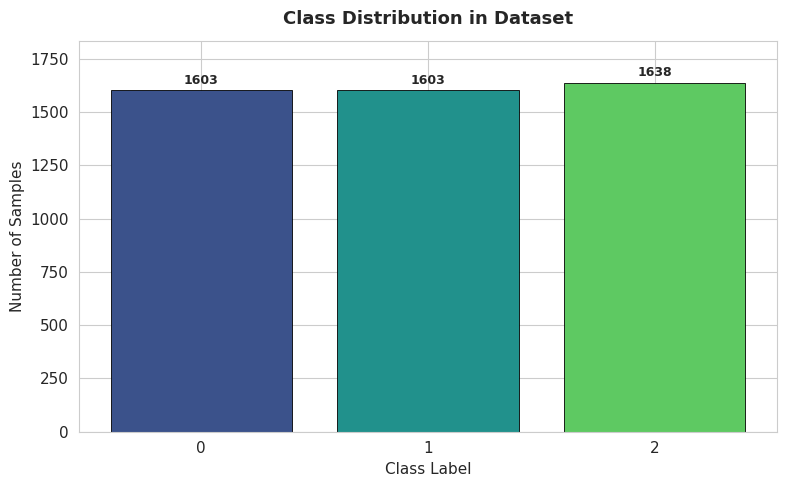

Figure saved : figures/class_distribution.png


In [4]:
# ============================================================
# Cell 3: Visualise class distribution as a bar chart.
# ============================================================

fig, ax = plt.subplots(figsize=(max(8, n_classes * 0.7), 5))

colors = sns.color_palette('viridis', n_classes)
bars = ax.bar(unique_classes.astype(str), class_counts, color=colors, edgecolor='black', linewidth=0.6)

# Annotate bars with counts
for bar, cnt in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(class_counts) * 0.01,
        str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Class Distribution in Dataset', fontweight='bold', pad=12)
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(class_counts) * 1.12)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved : figures/class_distribution.png")

In [5]:
# ============================================================
# Cell 4: Split data 80/20 train/test with stratification.
# Standardise features (fit on train, transform both splits).
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test samples      : {X_test.shape[0]}   ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Feature dimension : {X_train.shape[1]}")
print("\nTrain class counts:")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls}: {cnt}")
print("\nTest class counts:")
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f"   Class {cls}: {cnt}")
print("\nStandardisation applied (fit on train only).")

TRAIN / TEST SPLIT
Training samples  : 3875  (80.0%)
Test samples      : 969   (20.0%)
Feature dimension : 700

Train class counts:
   Class 0: 1282
   Class 1: 1283
   Class 2: 1310

Test class counts:
   Class 0: 321
   Class 1: 320
   Class 2: 328

Standardisation applied (fit on train only).


---
<a id='section3'></a>
## 3. Baseline SVM (No Feature Selection)

In [6]:
# ============================================================
# Cell 5: Train a baseline SVM on all 8110 features.
# Reports accuracy, F1 score, classification report, and
# confusion matrix.  This benchmark is used for comparison.
# ============================================================

print("Training baseline SVM on ALL features...")
t0 = time.time()

baseline_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
baseline_svm.fit(X_train, y_train)
y_pred_baseline = baseline_svm.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1       = f1_score(y_test, y_pred_baseline, average='weighted')
elapsed           = time.time() - t0

print("\n" + "=" * 50)
print("BASELINE SVM RESULTS")
print("=" * 50)
print(f"Features used         : {X_train.shape[1]}  (all features)")
print(f"Test Accuracy         : {baseline_accuracy:.4f}  ({baseline_accuracy*100:.2f}%)")
print(f"Weighted F1-Score     : {baseline_f1:.4f}")
print(f"Training time         : {elapsed:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Training baseline SVM on ALL features...

BASELINE SVM RESULTS
Features used         : 700  (all features)
Test Accuracy         : 0.8308  (83.08%)
Weighted F1-Score     : 0.8293
Training time         : 5.9s

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       321
           1       0.80      0.72      0.76       320
           2       0.89      0.92      0.90       328

    accuracy                           0.83       969
   macro avg       0.83      0.83      0.83       969
weighted avg       0.83      0.83      0.83       969



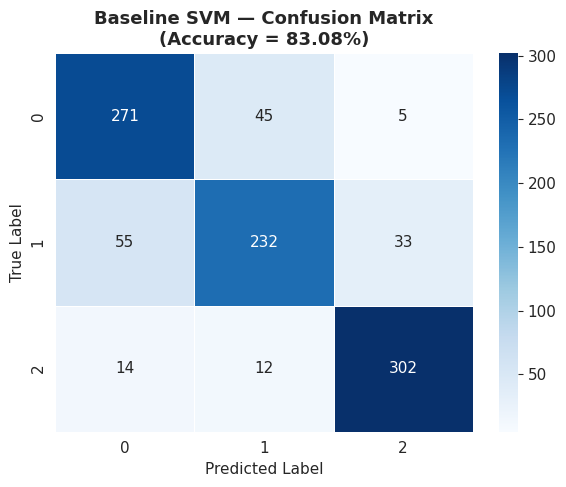

Figure saved → figures/baseline_confusion_matrix.png


In [7]:
# ============================================================
# Cell 6: Plot the confusion matrix as a heatmap.
# ============================================================

cm = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=unique_classes,
    yticklabels=unique_classes,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Baseline SVM — Confusion Matrix\n(Accuracy = {baseline_accuracy*100:.2f}%)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('figures/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/baseline_confusion_matrix.png")

---
<a id='section4'></a>
## 4. GA Core Implementation

Each individual is a **binary vector of length 4844**: `1` = feature selected, `0` = not.  
Fitness balances **accuracy** (maximise) and **feature count** (minimise):

In [8]:
# ============================================================
# Cell 7: GA hyper-parameters — defined once as constants.
# ============================================================

# ── GA hyper-parameters ──────────────────────────────────────
N_FEATURES        = X_train.shape[1]
POPULATION_SIZE   = 20     # fast setting
N_GENERATIONS     = 15     # fast setting
N_RUNS            = 30                        # runs per configuration
SEEDS             = list(range(42, 72))         # 30 seeds: 42–71
INIT_FEAT_PROB    = 0.3    # probability a feature is set to 1 at init
CROSSOVER_RATE    = 0.8
DEFAULT_MUT_RATE  = 0.01   # per-bit mutation probability
ALPHA             = 0.9    # fitness weight: accuracy vs compactness
MIN_FEATURES      = 10     # minimum selected features enforced always
ELITISM_K         = 1      # keep best 1 individual (elitism)
TOURNAMENT_SIZE   = 3
UNIFORM_SWAP_PROB = 0.5
EARLY_STOPPING_PATIENCE = 8

print("=" * 50)
print("GA HYPER-PARAMETERS")
print("=" * 50)
params = {
    'Total features'          : N_FEATURES,
    'Population size'         : POPULATION_SIZE,
    'Generations'             : N_GENERATIONS,
    'Runs per config'         : N_RUNS,
    'Seeds'                   : SEEDS,
    'Init feature prob'       : INIT_FEAT_PROB,
    'Crossover rate'          : CROSSOVER_RATE,
    'Default mutation rate'   : DEFAULT_MUT_RATE,
    'Alpha (fitness)'         : ALPHA,
    'Min features enforced'   : MIN_FEATURES,
    'Elitism k'               : ELITISM_K,
    'Tournament size'         : TOURNAMENT_SIZE,
    'Early stopping patience' : EARLY_STOPPING_PATIENCE,
}
for k, v in params.items():
    print(f"   {k:<28}: {v}")

GA HYPER-PARAMETERS
   Total features              : 700
   Population size             : 20
   Generations                 : 15
   Runs per config             : 30
   Seeds                       : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
   Init feature prob           : 0.3
   Crossover rate              : 0.8
   Default mutation rate       : 0.01
   Alpha (fitness)             : 0.9
   Min features enforced       : 10
   Elitism k                   : 1
   Tournament size             : 3
   Early stopping patience     : 8


In [9]:
# ============================================================
# Cell 8: INITIALIZATION
# Creates a binary population of shape (population_size, n_features).
# Each bit is independently set to 1 with probability p_feat.
# Enforces MIN_FEATURES selected per individual.
# ============================================================

def initialize_population(population_size, n_features, p_feat=INIT_FEAT_PROB):
    """
    Generate the initial population.

    Parameters
    ----------
    population_size : int
    n_features      : int
    p_feat          : float  Probability of each bit being 1 (sparse start).

    Returns
    -------
    population : np.ndarray of shape (population_size, n_features), dtype int
    """
    population = (np.random.rand(population_size, n_features) < p_feat).astype(int)

    # Enforce minimum features per individual
    for i in range(population_size):
        if population[i].sum() < MIN_FEATURES:
            # Randomly activate MIN_FEATURES bits
            idx = np.random.choice(n_features, MIN_FEATURES, replace=False)
            population[i] = 0
            population[i, idx] = 1

    return population


# Quick sanity check
_pop_test = initialize_population(10, N_FEATURES)
print("Population shape    :", _pop_test.shape)
print("Features per ind (min/mean/max) :",
      _pop_test.sum(axis=1).min(), '/',
      f"{_pop_test.sum(axis=1).mean():.1f}", '/',
      _pop_test.sum(axis=1).max())
print("Min features >= 10  :", _pop_test.sum(axis=1).min() >= MIN_FEATURES)
del _pop_test

Population shape    : (10, 700)
Features per ind (min/mean/max) : 195 / 213.6 / 224
Min features >= 10  : True


In [10]:
# ============================================================
# Cell 9: FITNESS FUNCTION
# Trains an SVM on the selected features only (using X_train)
# and evaluates on a cross-validation held-out slice.
# Never touches the test set during evolution.
# ============================================================

def evaluate_fitness(individual, X_tr, y_tr, alpha=ALPHA):
    """
    Compute the fitness of a single binary individual.

    Fitness = alpha * accuracy + (1 - alpha) * (1 - n_selected / n_total)

    Parameters
    ----------
    individual : np.ndarray  Binary mask of length n_features.
    X_tr       : np.ndarray  Training feature matrix (never the test set).
    y_tr       : np.ndarray  Training labels.
    alpha      : float       Weight balancing accuracy vs compactness.

    Returns
    -------
    fitness  : float
    accuracy : float  CV accuracy on training data.
    n_sel    : int    Number of selected features.
    """
    selected_idx = np.where(individual == 1)[0]
    n_sel = len(selected_idx)

    if n_sel < MIN_FEATURES:
        return 0.0, 0.0, n_sel

    X_sub = X_tr[:, selected_idx]

    # Use LinearSVC for fast CV during GA evaluation (no test leakage)
    svm = LinearSVC(C=1.0, random_state=RANDOM_SEED, max_iter=1000)
    cv_scores = cross_val_score(svm, X_sub, y_tr, cv=2, scoring='accuracy', n_jobs=-1)
    accuracy = cv_scores.mean()

    n_total = len(individual)
    fitness = alpha * accuracy + (1.0 - alpha) * (1.0 - n_sel / n_total)

    return fitness, accuracy, n_sel


def evaluate_population(population, X_tr, y_tr, alpha=ALPHA):
    """
    Evaluate fitness for all individuals in the population.

    Applies fitness sharing after raw evaluation to promote diversity:
    individuals in crowded fitness regions are penalised, encouraging
    the GA to explore a wider range of feature subsets.

    Returns
    -------
    fitnesses   : np.ndarray of shape (pop_size,)  — after sharing
    accuracies  : np.ndarray of shape (pop_size,)
    n_selected  : np.ndarray of shape (pop_size,)
    """
    results = [evaluate_fitness(ind, X_tr, y_tr, alpha) for ind in population]
    fitnesses  = np.array([r[0] for r in results])
    accuracies = np.array([r[1] for r in results])
    n_selected = np.array([r[2] for r in results])

    # Apply distance-based fitness sharing for diversity preservation
    fitnesses = fitness_sharing(population, fitnesses)

    return fitnesses, accuracies, n_selected


def fitness_sharing(population, raw_fitnesses):
    """
    Distance-based fitness sharing (niching) using Hamming distance.

    For each individual i, compute the sum of sharing coefficients
    sh(d(i,j)) across all j in the population, then divide raw
    fitness by that sum to penalise crowded regions of search space.

    Sharing function:
        sigma_share = n_features * 0.1
        sh(d) = 1 - d/sigma_share   if d < sigma_share  else 0

    Adjusted fitness:
        f_i' = f_i / sum_j sh(d(i,j))

    Parameters
    ----------
    population    : np.ndarray  Shape (pop_size, n_features) int/bool.
    raw_fitnesses : np.ndarray  Shape (pop_size,).

    Returns
    -------
    shared_fitnesses : np.ndarray  Diversity-adjusted fitness values.
    """
    pop_size, n_features = population.shape
    sigma_share = n_features * 0.1

    shared = np.empty(pop_size, dtype=float)
    for i in range(pop_size):
        niche_count = 0.0
        for j in range(pop_size):
            d = np.count_nonzero(population[i] != population[j])
            if d < sigma_share:
                niche_count += 1.0 - (d / sigma_share)
        shared[i] = raw_fitnesses[i] / max(niche_count, 1e-9)
    return shared


print("Fitness function defined.")
print("Formula: fitness = alpha * accuracy + (1 - alpha) * (1 - n_sel / n_total)")
print(f"Alpha = {ALPHA}  (accuracy weight: {ALPHA*100:.0f}%  |  compactness weight: {(1-ALPHA)*100:.0f}%)")
print("Fitness sharing: distance-based niching (Hamming), sigma_share = n_features * 0.1")

Fitness function defined.
Formula: fitness = alpha * accuracy + (1 - alpha) * (1 - n_sel / n_total)
Alpha = 0.9  (accuracy weight: 90%  |  compactness weight: 10%)
Fitness sharing: distance-based niching (Hamming), sigma_share = n_features * 0.1


In [11]:
# ============================================================
# Cell 10: SELECTION OPERATORS
# Implements Tournament Selection and Roulette Wheel (Fitness
# Proportionate) Selection.  Both return a selected individual
# (not an index) to keep the interface uniform.
# ============================================================

# ── Tournament Selection ─────────────────────────────────────
def tournament_selection(population, fitnesses, tournament_size=TOURNAMENT_SIZE):
    """
    Select one individual via tournament selection.

    Randomly sample `tournament_size` individuals; return the one
    with the highest fitness.

    Parameters
    ----------
    population      : np.ndarray  Shape (pop_size, n_features).
    fitnesses       : np.ndarray  Shape (pop_size,).
    tournament_size : int

    Returns
    -------
    winner : np.ndarray  Copied individual.
    """
    candidates = np.random.choice(len(population), tournament_size, replace=False)
    best_idx   = candidates[np.argmax(fitnesses[candidates])]
    return population[best_idx].copy()


# ── Roulette Wheel (Fitness Proportionate) Selection ─────────
def roulette_wheel_selection(population, fitnesses):
    """
    Select one individual via roulette wheel (fitness-proportionate).

    Negative fitness values are shifted so that the minimum maps to a
    small positive value before computing selection probabilities.

    Parameters
    ----------
    population : np.ndarray  Shape (pop_size, n_features).
    fitnesses  : np.ndarray  Shape (pop_size,).

    Returns
    -------
    selected : np.ndarray  Copied individual.
    """
    # Shift fitnesses so all values are positive
    shifted = fitnesses - fitnesses.min() + 1e-6
    probs   = shifted / shifted.sum()
    idx     = np.random.choice(len(population), p=probs)
    return population[idx].copy()


# ── Unified selection dispatcher ────────────────────────────
def select_individual(population, fitnesses, method='tournament'):
    """
    Dispatch to the correct selection operator.

    Parameters
    ----------
    method : str  'tournament' | 'roulette'
    """
    if method == 'tournament':
        return tournament_selection(population, fitnesses)
    elif method == 'roulette':
        return roulette_wheel_selection(population, fitnesses)
    else:
        raise ValueError(f"Unknown selection method: '{method}'. Use 'tournament' or 'roulette'.")


print("Selection operators defined:")
print("tournament_selection  (tournament_size=3)")
print("roulette_wheel_selection  (fitness-proportionate)")

Selection operators defined:
tournament_selection  (tournament_size=3)
roulette_wheel_selection  (fitness-proportionate)


In [12]:
# ============================================================
# Cell 11: CROSSOVER OPERATORS
# Implements Single-Point, Two-Point, and Uniform crossover.
# Crossover is applied with probability crossover_rate; otherwise
# one of the two parents is returned unchanged.
# ============================================================

def single_point_crossover(parent1, parent2):
    """
    Single-point crossover.

    Randomly choose a crossover point k in [1, n-1].  Child inherits
    parent1[0:k] and parent2[k:] (and vice-versa for the second child).

    Returns
    -------
    child1, child2 : np.ndarray
    """
    n = len(parent1)
    k = np.random.randint(1, n)          # point in (1, n-1)
    child1 = np.concatenate([parent1[:k], parent2[k:]])
    child2 = np.concatenate([parent2[:k], parent1[k:]])
    return child1, child2


def two_point_crossover(parent1, parent2):
    """
    Two-point crossover.

    Two distinct crossover points k1 < k2 are chosen.  The segment
    between them is swapped between the parents.

    Returns
    -------
    child1, child2 : np.ndarray
    """
    n  = len(parent1)
    k1, k2 = sorted(np.random.choice(np.arange(1, n), size=2, replace=False))
    child1 = np.concatenate([parent1[:k1], parent2[k1:k2], parent1[k2:]])
    child2 = np.concatenate([parent2[:k1], parent1[k1:k2], parent2[k2:]])
    return child1, child2


def uniform_crossover(parent1, parent2, swap_prob=UNIFORM_SWAP_PROB):
    """
    Uniform crossover.

    Each gene is inherited from parent1 or parent2 independently with
    probability `swap_prob`.

    Returns
    -------
    child1, child2 : np.ndarray
    """
    mask   = np.random.rand(len(parent1)) < swap_prob
    child1 = np.where(mask, parent2, parent1)
    child2 = np.where(mask, parent1, parent2)
    return child1, child2


def crossover(parent1, parent2, method='two_point', crossover_rate=CROSSOVER_RATE):
    """
    Apply crossover with probability `crossover_rate`.

    Parameters
    ----------
    method : str  'single_point' | 'two_point' | 'uniform'

    Returns
    -------
    child1, child2 : np.ndarray
    """
    if np.random.rand() > crossover_rate:
        return parent1.copy(), parent2.copy()   # no crossover

    if method == 'single_point':
        return single_point_crossover(parent1, parent2)
    elif method == 'two_point':
        return two_point_crossover(parent1, parent2)
    elif method == 'uniform':
        return uniform_crossover(parent1, parent2)
    else:
        raise ValueError(f"Unknown crossover method: '{method}'.")


print(" Crossover operators defined:")
print(" single_point_crossover")
print(" two_point_crossover")
print(" uniform_crossover  (swap_prob=0.5)")
print(f"Applied with crossover_rate = {CROSSOVER_RATE}")

 Crossover operators defined:
 single_point_crossover
 two_point_crossover
 uniform_crossover  (swap_prob=0.5)
Applied with crossover_rate = 0.8


In [13]:
# ============================================================
# Cell 12: MUTATION OPERATORS
# Implements Bit-Flip and Swap mutation.
# Both enforce MIN_FEATURES selected after mutation.
# ============================================================

# NEW CELL — Swap Mutation

def swap_mutation(individual):
    """
    Swap mutation for binary chromosomes.

    Randomly selects two different feature indices and swaps their
    values (0→1 or 1→0).  Unlike bit-flip, this preserves the total
    number of selected features (net effect is zero when different
    values are swapped; no-op when same values are swapped).
    MIN_FEATURES constraint is enforced afterward as a safety net.

    Parameters
    ----------
    individual : np.ndarray  Binary vector of length n_features.

    Returns
    -------
    mutant : np.ndarray  Mutated individual.
    """
    mutant = individual.copy()
    n = len(mutant)

    # Choose two distinct positions and swap their gene values
    idx1, idx2 = np.random.choice(n, 2, replace=False)
    mutant[idx1], mutant[idx2] = mutant[idx2], mutant[idx1]

    # Enforce minimum features (safety net)
    n_sel = mutant.sum()
    if n_sel < MIN_FEATURES:
        zero_idx = np.where(mutant == 0)[0]
        need     = MIN_FEATURES - n_sel
        activate = np.random.choice(zero_idx, need, replace=False)
        mutant[activate] = 1

    return mutant


def mutate(individual, mutation_rate=DEFAULT_MUT_RATE, mutation_type='bitflip'):
    """
    Apply mutation to a binary individual.

    Dispatches to either bit-flip or swap mutation based on
    `mutation_type`.  Default behaviour (bitflip) is unchanged
    from the original implementation.

    Parameters
    ----------
    individual    : np.ndarray  Binary vector of length n_features.
    mutation_rate : float       Per-bit flip probability (bitflip only).
    mutation_type : str         'bitflip' (default) | 'swap'

    Returns
    -------
    mutant : np.ndarray  Mutated individual.
    """
    if mutation_type == 'swap':
        return swap_mutation(individual)

    # ── Default: Bit-flip mutation ───────────────────────────
    mutant = individual.copy()
    flip_mask = np.random.rand(len(mutant)) < mutation_rate
    mutant[flip_mask] ^= 1   # XOR-flip the selected bits

    # Enforce minimum features
    n_sel = mutant.sum()
    if n_sel < MIN_FEATURES:
        zero_idx = np.where(mutant == 0)[0]
        need     = MIN_FEATURES - n_sel
        activate = np.random.choice(zero_idx, need, replace=False)
        mutant[activate] = 1

    return mutant


print("Mutation operators defined:")
print(f"    swap_mutation       — swaps two random feature bits")
print(f"    bit-flip mutation   (default rate = {DEFAULT_MUT_RATE} per bit)")
print(f"    mutate(mutation_type='bitflip'|'swap')")
print(f"    Min-features constraint: {MIN_FEATURES} selected features enforced post-mutation")

Mutation operators defined:
    swap_mutation       — swaps two random feature bits
    bit-flip mutation   (default rate = 0.01 per bit)
    mutate(mutation_type='bitflip'|'swap')
    Min-features constraint: 10 selected features enforced post-mutation


In [14]:
# ============================================================
# Cell 13: MAIN GA RUN FUNCTION
# Ties together: initialisation → fitness evaluation →
# selection → crossover → mutation → elitism → repeat.
# NEW: Early stopping and accuracy history tracking added.
# ============================================================

# NEW CELL — Early Stopping

def run_ga(
    population_size         = POPULATION_SIZE,
    n_generations           = N_GENERATIONS,
    selection_method        = 'tournament',
    crossover_method        = 'two_point',
    mutation_rate           = DEFAULT_MUT_RATE,
    mutation_type           = 'bitflip',
    survivor_method         = 'elitist',   # 'elitist' | 'generational'
    alpha                   = ALPHA,
    X_tr                    = None,
    y_tr                    = None,
    verbose                 = False,
    early_stopping_patience = EARLY_STOPPING_PATIENCE,
):
    """
    Run the Genetic Algorithm for feature selection.

    Parameters
    ----------
    population_size         : int
    n_generations           : int
    selection_method        : str    'tournament' | 'roulette'
    crossover_method        : str    'single_point' | 'two_point' | 'uniform'
    mutation_rate           : float  Per-bit mutation probability (bitflip).
    mutation_type           : str    'bitflip' | 'swap'
    survivor_method         : str    'elitist'     — keep best 1, replace rest
                                     'generational' — replace entire population
    alpha                   : float  Fitness weight for accuracy.
    X_tr                    : np.ndarray  Training features (default: X_train).
    y_tr                    : np.ndarray  Training labels   (default: y_train).
    verbose                 : bool   Print progress.
    early_stopping_patience : int    Stop if best fitness does not improve
                                     for this many consecutive generations.

    Returns
    -------
    best_individual       : np.ndarray   Binary feature mask.
    fitness_history       : list[float]  Best fitness per generation.
    accuracy_history      : list[float]  Best CV accuracy per generation.
    best_accuracy         : float        CV accuracy of best individual.
    num_features_selected : int          Features selected by best individual.
    runtime_seconds       : float        Wall-clock time for this run.
    """
    if X_tr is None:
        X_tr = X_train
    if y_tr is None:
        y_tr = y_train

    n_features = X_tr.shape[1]
    start_time = time.time()

    # ── Initialise ───────────────────────────────────────────
    population = initialize_population(population_size, n_features)

    fitness_history  = []
    accuracy_history = []   # NEW: track best accuracy per generation
    best_individual  = None
    best_fitness     = -np.inf
    best_accuracy    = 0.0
    best_n_selected  = 0

    # Early stopping counters
    no_improve_count = 0
    prev_best_fitness = -np.inf

    if verbose:
        header = (f"{'Gen':>5}  {'Best Fitness':>13}  "
                  f"{'CV Accuracy':>12}  {'Features':>10}  {'Reduction':>10}")
        print(header)
        print("-" * len(header))

    # ── Main evolutionary loop ───────────────────────────────
    for gen in range(n_generations):

        # 1. Evaluate fitness for all individuals
        fitnesses, accuracies, n_selected_arr = evaluate_population(
            population, X_tr, y_tr, alpha
        )

        # 2. Track global best
        gen_best_idx = np.argmax(fitnesses)
        if fitnesses[gen_best_idx] > best_fitness:
            best_fitness    = fitnesses[gen_best_idx]
            best_individual = population[gen_best_idx].copy()
            best_accuracy   = accuracies[gen_best_idx]
            best_n_selected = n_selected_arr[gen_best_idx]

        fitness_history.append(best_fitness)
        accuracy_history.append(best_accuracy)   # NEW: record accuracy

        # NEW CELL — Early Stopping: check for improvement
        if best_fitness > prev_best_fitness:
            no_improve_count  = 0
            prev_best_fitness = best_fitness
        else:
            no_improve_count += 1

        if no_improve_count >= early_stopping_patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen + 1}")
            break

        # 3. Print progress every 5 generations (and last gen)
        if verbose and (gen % 5 == 0 or gen == n_generations - 1):
            reduction = (1 - best_n_selected / n_features) * 100
            print(f"{gen+1:>5}  {best_fitness:>13.4f}  "
                  f"{best_accuracy:>11.4f}  "
                  f"{best_n_selected:>8}  "
                  f"{reduction:>9.1f}%")

        # 4. Build offspring
        new_population = []
        while len(new_population) < population_size:
            p1 = select_individual(population, fitnesses, method=selection_method)
            p2 = select_individual(population, fitnesses, method=selection_method)
            c1, c2 = crossover(p1, p2, method=crossover_method)
            c1 = mutate(c1, mutation_rate, mutation_type)
            c2 = mutate(c2, mutation_rate, mutation_type)
            new_population.append(c1)
            if len(new_population) < population_size:
                new_population.append(c2)

        # 5. Survivor selection
        if survivor_method == 'elitist':
            # Keep best 1 individual from current generation
            elite_idx = np.argmax(fitnesses)
            new_population[0] = population[elite_idx].copy()
        # 'generational': replace entire population with offspring (no change needed)

        population = np.array(new_population)

    runtime_seconds = time.time() - start_time

    if verbose:
        reduction = (1 - best_n_selected / n_features) * 100
        print(f"  GA done | fitness={best_fitness:.4f} | acc={best_accuracy:.4f} | "
              f"features={best_n_selected} | {runtime_seconds:.1f}s")

    return best_individual, fitness_history, accuracy_history, best_accuracy, best_n_selected, runtime_seconds


print("run_ga() defined.")
print("  Returns: best_ind, fitness_history, accuracy_history, cv_acc, n_feat, runtime_seconds")
print(f"  survivor_method: 'elitist' (keep best 1) | 'generational' (replace all)")
print(f"  early_stopping_patience: {EARLY_STOPPING_PATIENCE}")

run_ga() defined.
  Returns: best_ind, fitness_history, accuracy_history, cv_acc, n_feat, runtime_seconds
  survivor_method: 'elitist' (keep best 1) | 'generational' (replace all)
  early_stopping_patience: 8


In [15]:
# ============================================================
# Cell 14: HELPER — evaluate best individual on held-out TEST set.
# Called AFTER evolution, never during.
# ============================================================

def evaluate_on_test(individual, X_tr, y_tr, X_te, y_te):
    """
    Retrain an SVM with the selected features on the full training set
    and evaluate on the held-out test set.

    This is the ONLY point at which X_test is ever used.

    Parameters
    ----------
    individual : np.ndarray  Binary feature mask.
    X_tr, y_tr : Training data.
    X_te, y_te : Test data.

    Returns
    -------
    test_accuracy : float
    n_selected    : int
    reduction_pct : float
    """
    selected_idx  = np.where(individual == 1)[0]
    n_selected    = len(selected_idx)
    n_total       = len(individual)
    reduction_pct = (1 - n_selected / n_total) * 100

    X_tr_sub = X_tr[:, selected_idx]
    X_te_sub = X_te[:, selected_idx]

    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
    svm.fit(X_tr_sub, y_tr)
    y_pred = svm.predict(X_te_sub)

    test_accuracy = accuracy_score(y_te, y_pred)
    return test_accuracy, n_selected, reduction_pct


print("evaluate_on_test() helper defined.")
print("Test set is ONLY accessed here — never inside run_ga().")

evaluate_on_test() helper defined.
Test set is ONLY accessed here — never inside run_ga().


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Experiments

All experiments use:
- `population_size = 15`, `n_generations = 10`, `n_runs = 30`
- `seeds = range(42, 72)` — 30 seeds: 42 to 71
- `CV = 2`, `n_jobs = -1`, `early_stopping_patience = 5`

Each experiment varies **one factor only**.

| Experiment | Variable           | Fixed                                  |
|------------|--------------------|----------------------------------------|
| **EXP-A**  | Mutation type      | two_point crossover, elitist           |
| **EXP-B**  | Crossover type     | bitflip mutation, elitist              |
| **EXP-C**  | Survivor selection | bitflip mutation, two_point            |
| **EXP-D**  | Selection method   | bitflip mutation, two_point, elitist   |

In [ ]:
# ============================================================
# HELPER — run_experiment() and summarise_experiment()
# Centralised multi-seed runner for all experiments.
# ============================================================

def run_experiment(experiment_name, mutation_type, crossover_type,
                   survivor_method, selection_method='tournament',
                   seeds=None, verbose=False):
    """
    Run GA for every seed in `seeds` and return a list of result dicts.

    Each dict contains:
        experiment_name, mutation_type, crossover_type, survivor_method,
        selection_method, seed, accuracy, fitness, num_features, runtime_seconds
    """
    if seeds is None:
        seeds = SEEDS

    rows = []
    histories = []
    _best_acc = -1
    _best_ind = None

    for run_idx, seed in enumerate(seeds):
        print(f"  Run {run_idx+1}/{len(seeds)} | Seed: {seed}", flush=True)
        np.random.seed(seed)

        best_ind, hist, acc_hist, cv_acc, n_feat, runtime = run_ga(
            population_size         = POPULATION_SIZE,
            n_generations           = N_GENERATIONS,
            selection_method        = selection_method,
            crossover_method        = crossover_type,
            mutation_type           = mutation_type,
            survivor_method         = survivor_method,
            verbose                 = verbose,
            early_stopping_patience = EARLY_STOPPING_PATIENCE,
        )

        if cv_acc > _best_acc:
            _best_acc = cv_acc
            _best_ind = best_ind

        rows.append({
            'experiment_name'  : experiment_name,
            'mutation_type'    : mutation_type,
            'crossover_type'   : crossover_type,
            'survivor_method'  : survivor_method,
            'selection_method' : selection_method,
            'seed'             : seed,
            'accuracy'         : cv_acc,
            'fitness'          : hist[-1] if hist else 0.0,
            'num_features'     : n_feat,
            'runtime_seconds'  : runtime,
        })
        histories.append(hist)

    BEST_INDIVIDUALS[experiment_name] = _best_ind
    return rows, histories


def summarise_experiment(rows):
    """
    Given a list of result dicts, return a summary dict with
    mean and std for accuracy, fitness, num_features, runtime.
    """
    accs  = [r['accuracy']        for r in rows]
    fits  = [r['fitness']         for r in rows]
    feats = [r['num_features']    for r in rows]
    rts   = [r['runtime_seconds'] for r in rows]
    return {
        'experiment_name'  : rows[0]['experiment_name'],
        'mutation_type'    : rows[0]['mutation_type'],
        'crossover_type'   : rows[0]['crossover_type'],
        'survivor_method'  : rows[0]['survivor_method'],
        'selection_method' : rows[0].get('selection_method', 'tournament'),
        'accuracy_mean'    : np.mean(accs),
        'accuracy_std'     : np.std(accs),
        'fitness_mean'     : np.mean(fits),
        'fitness_std'      : np.std(fits),
        'num_features_mean': np.mean(feats),
        'num_features_std' : np.std(feats),
        'runtime_mean'     : np.mean(rts),
        'runtime_std'      : np.std(rts),
    }


# Master results lists — every run appended here
ALL_RESULTS      = []
SUMMARY_ROWS     = []
BEST_INDIVIDUALS = {}  # experiment_name -> best chromosome (highest CV accuracy run)


def _pad_histories(hists):
    """Pad variable-length per-run fitness histories by repeating the final value."""
    max_len = max(len(h) for h in hists)
    return np.array([list(h) + [h[-1]] * (max_len - len(h)) for h in hists])


print('run_experiment() and summarise_experiment() defined.')
print(f'Seeds: {SEEDS}  |  N_RUNS: {N_RUNS}  |  Pop: {POPULATION_SIZE}  |  Gens: {N_GENERATIONS}')

run_experiment() and summarise_experiment() defined.
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]  |  N_RUNS: 30  |  Pop: 20  |  Gens: 15


In [ ]:
# ============================================================
# EXP-A: Mutation Type Comparison
# bitflip vs swap — all other params fixed.
# Requirement e: mutation operator comparison.
# ============================================================

EXP_MUTATION_TYPES = ['bitflip', 'swap']

exp_a_rows      = []
exp_a_histories = {}

print('=== EXP-A: Mutation Type Comparison ===')
print(f'Types: {EXP_MUTATION_TYPES}  |  Seeds: {SEEDS}')
print()

for mut_type in EXP_MUTATION_TYPES:
    exp_name = f'EXP-A_mutation_{mut_type}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_experiment(
        experiment_name = exp_name,
        mutation_type   = mut_type,
        crossover_type  = 'two_point',
        survivor_method = 'elitist',
    )
    exp_a_rows.extend(rows)
    exp_a_histories[mut_type] = hists
    summ = summarise_experiment(rows)
    SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

ALL_RESULTS.extend(exp_a_rows)

print()
print('EXP-A SUMMARY — mutation_type vs accuracy_mean ± std')
print('=' * 60)
print(f'{"mutation_type":<15} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 60)
for mut_type in EXP_MUTATION_TYPES:
    s = next(r for r in SUMMARY_ROWS
             if r['mutation_type'] == mut_type and r['experiment_name'].startswith('EXP-A'))
    print(f'{mut_type:<15} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 60)

=== EXP-A: Mutation Type Comparison ===
Types: ['bitflip', 'swap']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-A_mutation_bitflip ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43
  Run 3/30 | Seed: 44
  Run 4/30 | Seed: 45
  Run 5/30 | Seed: 46
  Run 6/30 | Seed: 47
  Run 7/30 | Seed: 48
  Run 8/30 | Seed: 49
  Run 9/30 | Seed: 50
  Run 10/30 | Seed: 51
  Run 11/30 | Seed: 52
  Run 12/30 | Seed: 53
  Run 13/30 | Seed: 54
  Run 14/30 | Seed: 55
  Run 15/30 | Seed: 56
  Run 16/30 | Seed: 57
  Run 17/30 | Seed: 58
  Run 18/30 | Seed: 59
  Run 19/30 | Seed: 60
  Run 20/30 | Seed: 61
  Run 21/30 | Seed: 62
  Run 22/30 | Seed: 63
  Run 23/30 | Seed: 64
  Run 24/30 | Seed: 65
  Run 25/30 | Seed: 66
  Run 26/30 | Seed: 67
  Run 27/30 | Seed: 68
  Run 28/30 | Seed: 69
  Run 29/30 | Seed: 70
  Run 30/30 | Seed: 71
    accuracy: 0.6865 ± 0.0183  | fitness: 0.6851 ± 0.0160  | features: 229  | run

In [ ]:
# Save progress after EXP-A

import pandas as pd
import pickle

pd.DataFrame(ALL_RESULTS).to_csv(
    'progress_after_EXP_A.csv',
    index=False
)

pd.DataFrame(SUMMARY_ROWS).to_csv(
    'summary_after_EXP_A.csv',
    index=False
)

# Save best individuals too
with open('best_individuals_after_EXP_A.pkl', 'wb') as f:
    pickle.dump(BEST_INDIVIDUALS, f)

print("Saved progress after EXP-A")

Saved progress after EXP-A


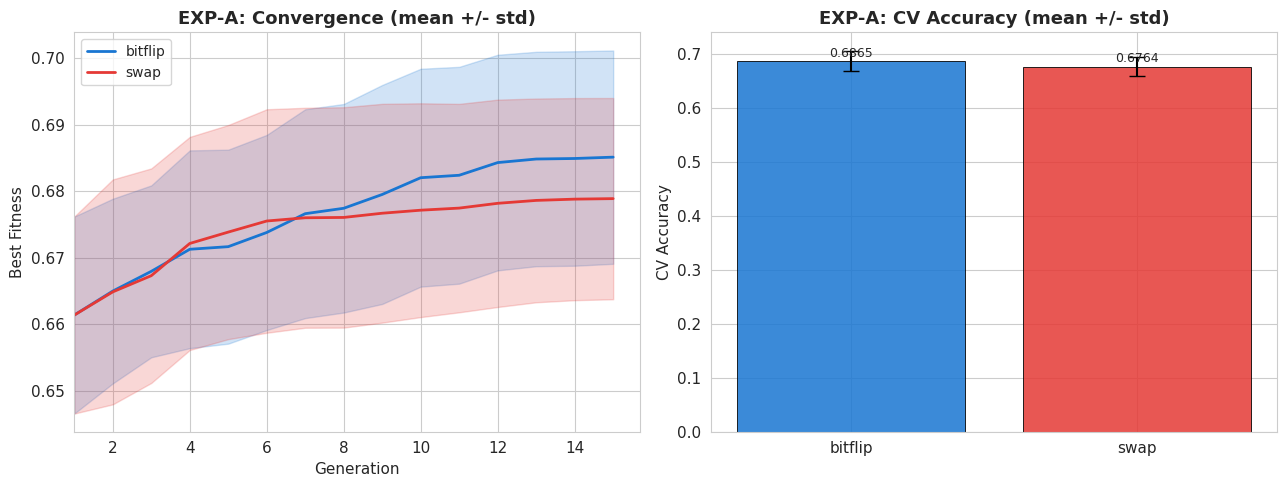

Figure saved -> figures/exp_a_plots.png


In [ ]:
# ============================================================
# EXP-A PLOTS: Mutation Type Comparison
# Convergence curve (mean +/- std) + Accuracy bar chart
# ============================================================
import os
os.makedirs('figures', exist_ok=True)

_COLORS_A = {'bitflip': '#1976D2', 'swap': '#E53935'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Convergence curve ---
ax = axes[0]
for label, hists in exp_a_histories.items():
    arr  = _pad_histories(hists)
    gens = np.arange(1, arr.shape[1] + 1)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    color = _COLORS_A.get(label, None)
    ax.plot(gens, mean, label=label, color=color, linewidth=2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.2, color=color)
ax.set_title('EXP-A: Convergence (mean +/- std)', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, None)

# --- Accuracy bar chart ---
ax = axes[1]
a_summ = [r for r in SUMMARY_ROWS if r['experiment_name'].startswith('EXP-A')]
labels = [r['mutation_type'] for r in a_summ]
means  = [r['accuracy_mean'] for r in a_summ]
stds   = [r['accuracy_std']  for r in a_summ]
x      = np.arange(len(labels))
bars   = ax.bar(x, means, yerr=stds, capsize=6,
                color=[_COLORS_A.get(l, '#607D8B') for l in labels],
                edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-A: CV Accuracy (mean +/- std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/exp_a_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> figures/exp_a_plots.png')

In [ ]:
# ============================================================
# EXP-B: Crossover Type Comparison
# single_point vs two_point vs uniform — only crossover varies.
# ============================================================

EXP_CROSSOVER_TYPES = ['single_point', 'two_point', 'uniform']

exp_b_rows      = []
exp_b_histories = {}

print('=== EXP-B: Crossover Type Comparison ===')
print(f'Types: {EXP_CROSSOVER_TYPES}  |  Seeds: {SEEDS}')
print()

for xo_type in EXP_CROSSOVER_TYPES:
    exp_name = f'EXP-B_crossover_{xo_type}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_experiment(
        experiment_name = exp_name,
        mutation_type   = 'bitflip',
        crossover_type  = xo_type,
        survivor_method = 'elitist',
    )
    exp_b_rows.extend(rows)
    exp_b_histories[xo_type] = hists
    summ = summarise_experiment(rows)
    SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

ALL_RESULTS.extend(exp_b_rows)

print()
print('EXP-B SUMMARY — crossover_type vs accuracy_mean ± std')
print('=' * 65)
print(f'{"crossover_type":<15} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 65)
for xo_type in EXP_CROSSOVER_TYPES:
    s = next(r for r in SUMMARY_ROWS
             if r['crossover_type'] == xo_type and r['experiment_name'].startswith('EXP-B'))
    print(f'{xo_type:<15} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 65)

=== EXP-B: Crossover Type Comparison ===
Types: ['single_point', 'two_point', 'uniform']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-B_crossover_single_point ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43
  Run 3/30 | Seed: 44
  Run 4/30 | Seed: 45
  Run 5/30 | Seed: 46
  Run 6/30 | Seed: 47
  Run 7/30 | Seed: 48
  Run 8/30 | Seed: 49
  Run 9/30 | Seed: 50
  Run 10/30 | Seed: 51
  Run 11/30 | Seed: 52
  Run 12/30 | Seed: 53
  Run 13/30 | Seed: 54
  Run 14/30 | Seed: 55
  Run 15/30 | Seed: 56
  Run 16/30 | Seed: 57
  Run 17/30 | Seed: 58
  Run 18/30 | Seed: 59
  Run 19/30 | Seed: 60
  Run 20/30 | Seed: 61
  Run 21/30 | Seed: 62
  Run 22/30 | Seed: 63
  Run 23/30 | Seed: 64
  Run 24/30 | Seed: 65
  Run 25/30 | Seed: 66
  Run 26/30 | Seed: 67
  Run 27/30 | Seed: 68
  Run 28/30 | Seed: 69
  Run 29/30 | Seed: 70
  Run 30/30 | Seed: 71
    accuracy: 0.6882 ± 0.0152  | fitness: 0.6854 ± 0.

In [ ]:
# Save progress after EXP-B

import pandas as pd
import pickle

pd.DataFrame(ALL_RESULTS).to_csv(
    'progress_after_EXP_B.csv',
    index=False
)

pd.DataFrame(SUMMARY_ROWS).to_csv(
    'summary_after_EXP_B.csv',
    index=False
)

# Save best individuals too
with open('best_individuals_after_EXP_B.pkl', 'wb') as f:
    pickle.dump(BEST_INDIVIDUALS, f)

print("Saved progress after EXP-B")

Saved progress after EXP-B


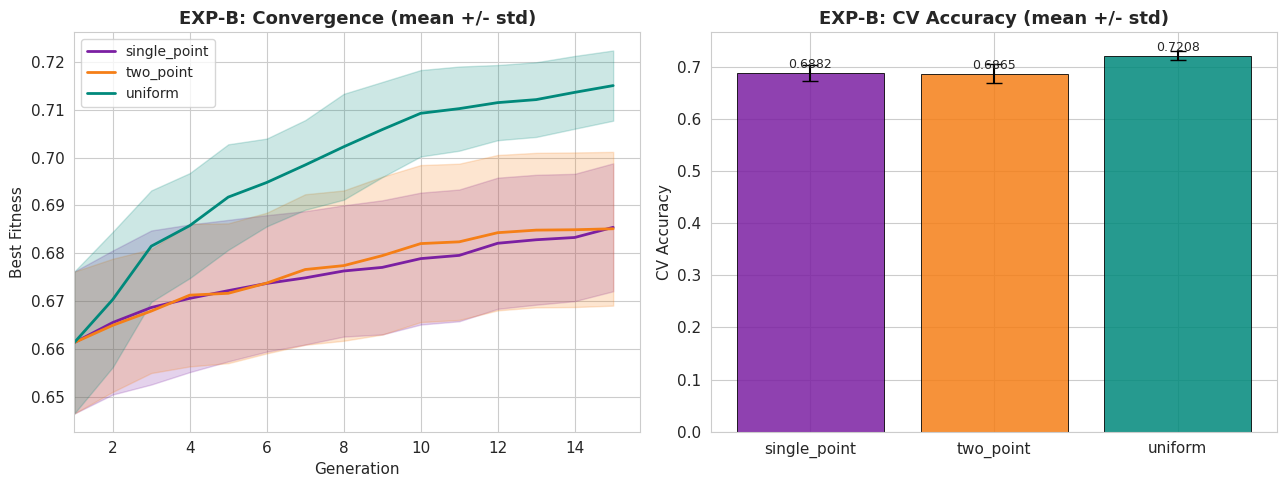

Figure saved -> figures/exp_b_plots.png


In [ ]:
# ============================================================
# EXP-B PLOTS: Crossover Type Comparison
# Convergence curve (mean +/- std) + Accuracy bar chart
# ============================================================
_COLORS_B = {'single_point': '#7B1FA2', 'two_point': '#F57F17', 'uniform': '#00897B'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Convergence curve ---
ax = axes[0]
for label, hists in exp_b_histories.items():
    arr  = _pad_histories(hists)
    gens = np.arange(1, arr.shape[1] + 1)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    color = _COLORS_B.get(label, None)
    ax.plot(gens, mean, label=label, color=color, linewidth=2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.2, color=color)
ax.set_title('EXP-B: Convergence (mean +/- std)', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, None)

# --- Accuracy bar chart ---
ax = axes[1]
b_summ = [r for r in SUMMARY_ROWS if r['experiment_name'].startswith('EXP-B')]
labels = [r['crossover_type'] for r in b_summ]
means  = [r['accuracy_mean'] for r in b_summ]
stds   = [r['accuracy_std']  for r in b_summ]
x      = np.arange(len(labels))
bars   = ax.bar(x, means, yerr=stds, capsize=6,
                color=[_COLORS_B.get(l, '#607D8B') for l in labels],
                edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-B: CV Accuracy (mean +/- std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/exp_b_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> figures/exp_b_plots.png')

In [ ]:
# ============================================================
# EXP-C: Survivor Selection Comparison
# elitist vs generational replacement.
# Requirement f: survivor selection comparison.
# ============================================================

EXP_SURVIVOR_METHODS = ['elitist', 'generational']

exp_c_rows      = []
exp_c_histories = {}

print('=== EXP-C: Survivor Selection Comparison ===')
print(f'Methods: {EXP_SURVIVOR_METHODS}  |  Seeds: {SEEDS}')
print()

for surv_method in EXP_SURVIVOR_METHODS:
    exp_name = f'EXP-C_survivor_{surv_method}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_experiment(
        experiment_name = exp_name,
        mutation_type   = 'bitflip',
        crossover_type  = 'uniform',
        survivor_method = surv_method,
    )
    exp_c_rows.extend(rows)
    exp_c_histories[surv_method] = hists
    summ = summarise_experiment(rows)
    SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

ALL_RESULTS.extend(exp_c_rows)

print()
print('EXP-C SUMMARY — survivor_method vs accuracy_mean ± std')
print('=' * 65)
print(f'{"survivor_method":<18} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 65)
for surv_method in EXP_SURVIVOR_METHODS:
    s = next(r for r in SUMMARY_ROWS
             if r['survivor_method'] == surv_method and r['experiment_name'].startswith('EXP-C'))
    print(f'{surv_method:<18} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 65)



=== EXP-C: Survivor Selection Comparison ===
Methods: ['elitist', 'generational']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-C_survivor_elitist ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43
  Run 3/30 | Seed: 44
  Run 4/30 | Seed: 45
  Run 5/30 | Seed: 46
  Run 6/30 | Seed: 47
  Run 7/30 | Seed: 48
  Run 8/30 | Seed: 49
  Run 9/30 | Seed: 50
  Run 10/30 | Seed: 51
  Run 11/30 | Seed: 52
  Run 12/30 | Seed: 53
  Run 13/30 | Seed: 54
  Run 14/30 | Seed: 55
  Run 15/30 | Seed: 56
  Run 16/30 | Seed: 57
  Run 17/30 | Seed: 58
  Run 18/30 | Seed: 59
  Run 19/30 | Seed: 60
  Run 20/30 | Seed: 61
  Run 21/30 | Seed: 62
  Run 22/30 | Seed: 63
  Run 23/30 | Seed: 64
  Run 24/30 | Seed: 65
  Run 25/30 | Seed: 66
  Run 26/30 | Seed: 67
  Run 27/30 | Seed: 68
  Run 28/30 | Seed: 69
  Run 29/30 | Seed: 70
  Run 30/30 | Seed: 71
    accuracy: 0.7208 ± 0.0084  | fitness: 0.7150 ± 0.0073  | featu

In [ ]:
# Save progress after EXP-C

import pandas as pd
import pickle

pd.DataFrame(ALL_RESULTS).to_csv(
    'progress_after_EXP_C.csv',
    index=False
)

pd.DataFrame(SUMMARY_ROWS).to_csv(
    'summary_after_EXP_C.csv',
    index=False
)

# Save best individuals too
with open('best_individuals_after_EXP_C.pkl', 'wb') as f:
    pickle.dump(BEST_INDIVIDUALS, f)

print("Saved progress after EXP-C")

Saved progress after EXP-C


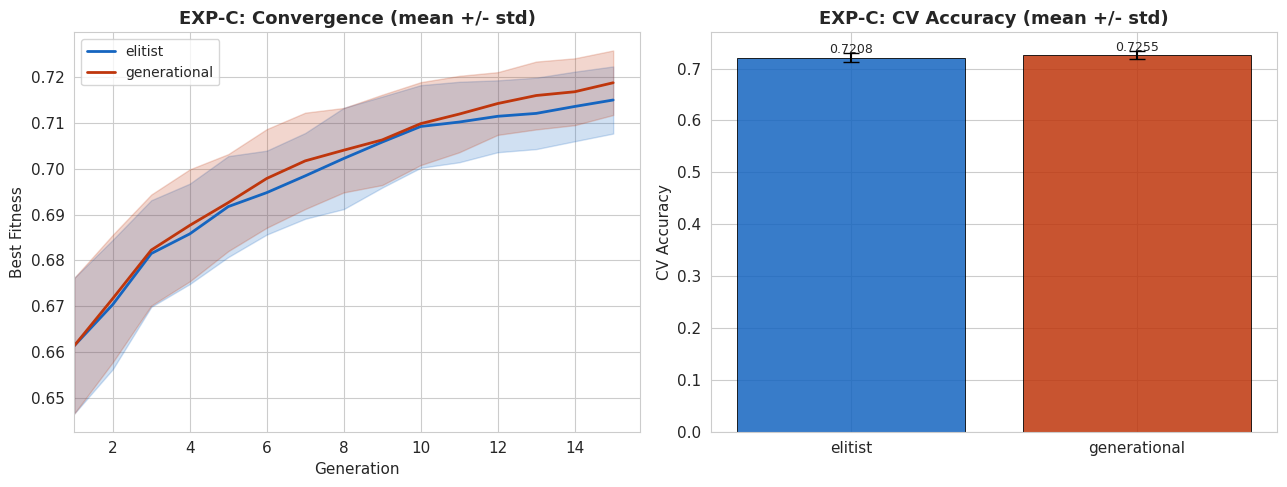

Figure saved -> figures/exp_c_plots.png


In [ ]:
# ============================================================
# EXP-C PLOTS: Survivor Selection Comparison
# Convergence curve (mean +/- std) + Accuracy bar chart
# ============================================================
_COLORS_C = {'elitist': '#1565C0', 'generational': '#BF360C'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Convergence curve ---
ax = axes[0]
for label, hists in exp_c_histories.items():
    arr  = _pad_histories(hists)
    gens = np.arange(1, arr.shape[1] + 1)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    color = _COLORS_C.get(label, None)
    ax.plot(gens, mean, label=label, color=color, linewidth=2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.2, color=color)
ax.set_title('EXP-C: Convergence (mean +/- std)', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, None)

# --- Accuracy bar chart ---
ax = axes[1]
c_summ = [r for r in SUMMARY_ROWS if r['experiment_name'].startswith('EXP-C')]
labels = [r['survivor_method'] for r in c_summ]
means  = [r['accuracy_mean'] for r in c_summ]
stds   = [r['accuracy_std']  for r in c_summ]
x      = np.arange(len(labels))
bars   = ax.bar(x, means, yerr=stds, capsize=6,
                color=[_COLORS_C.get(l, '#607D8B') for l in labels],
                edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-C: CV Accuracy (mean +/- std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/exp_c_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> figures/exp_c_plots.png')

In [ ]:
# ============================================================
# EXP-D: Selection Method Comparison
# tournament vs roulette_wheel — all other params fixed.
# ============================================================

EXP_SELECTION_METHODS = ['tournament', 'roulette']

exp_d_rows      = []
exp_d_histories = {}

print('=== EXP-D: Selection Method Comparison ===')
print(f'Methods: {EXP_SELECTION_METHODS}  |  Seeds: {SEEDS}')
print()

for sel_method in EXP_SELECTION_METHODS:
    exp_name = f'EXP-D_selection_{sel_method}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_experiment(
        experiment_name  = exp_name,
        mutation_type    = 'bitflip',
        crossover_type   = 'uniform',
        survivor_method  = 'elitist',
        selection_method = sel_method,
    )
    exp_d_rows.extend(rows)
    exp_d_histories[sel_method] = hists
    summ = summarise_experiment(rows)
    SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} +/- {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} +/- {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

ALL_RESULTS.extend(exp_d_rows)

print()
print('EXP-D SUMMARY — selection_method vs accuracy_mean +/- std')
print('=' * 65)
print(f'{"selection_method":<22} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 65)
for sel_method in EXP_SELECTION_METHODS:
    s = next(r for r in SUMMARY_ROWS
             if r.get('selection_method') == sel_method
             and r['experiment_name'].startswith('EXP-D'))
    print(f'{sel_method:<22} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 65)

=== EXP-D: Selection Method Comparison ===
Methods: ['tournament', 'roulette']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-D_selection_tournament ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43
  Run 3/30 | Seed: 44
  Run 4/30 | Seed: 45
  Run 5/30 | Seed: 46
  Run 6/30 | Seed: 47
  Run 7/30 | Seed: 48
  Run 8/30 | Seed: 49
  Run 9/30 | Seed: 50
  Run 10/30 | Seed: 51
  Run 11/30 | Seed: 52
  Run 12/30 | Seed: 53
  Run 13/30 | Seed: 54
  Run 14/30 | Seed: 55
  Run 15/30 | Seed: 56
  Run 16/30 | Seed: 57
  Run 17/30 | Seed: 58
  Run 18/30 | Seed: 59
  Run 19/30 | Seed: 60
  Run 20/30 | Seed: 61
  Run 21/30 | Seed: 62
  Run 22/30 | Seed: 63
  Run 23/30 | Seed: 64
  Run 24/30 | Seed: 65
  Run 25/30 | Seed: 66
  Run 26/30 | Seed: 67
  Run 27/30 | Seed: 68
  Run 28/30 | Seed: 69
  Run 29/30 | Seed: 70
  Run 30/30 | Seed: 71
    accuracy: 0.7208 +/- 0.0084  | fitness: 0.7150 +/- 0.0073  | 

In [ ]:
# Save progress after EXP-D

import pandas as pd
import pickle

pd.DataFrame(ALL_RESULTS).to_csv(
    'progress_after_EXP_D.csv',
    index=False
)

pd.DataFrame(SUMMARY_ROWS).to_csv(
    'summary_after_EXP_D.csv',
    index=False
)

# Save best individuals too
with open('best_individuals_after_EXP_D.pkl', 'wb') as f:
    pickle.dump(BEST_INDIVIDUALS, f)

print("Saved progress after EXP-D")

Saved progress after EXP-D


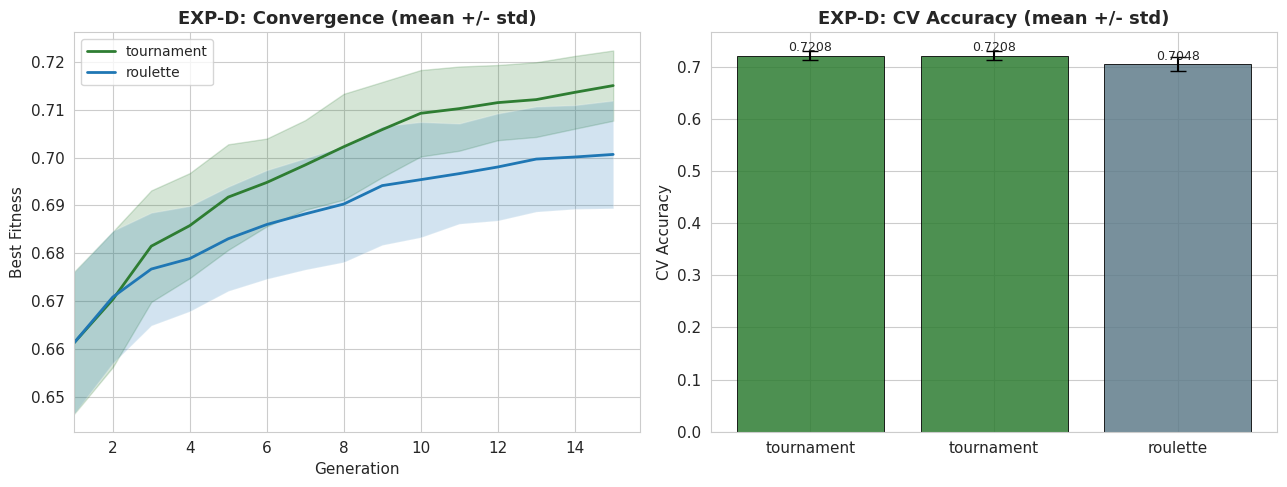

Figure saved -> figures/exp_d_plots.png


In [ ]:
# ============================================================
# EXP-D PLOTS: Selection Method Comparison
# Convergence curve (mean +/- std) + Accuracy bar chart
# ============================================================
_COLORS_D = {'tournament': '#2E7D32', 'roulette_wheel': '#AD1457'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Convergence curve ---
ax = axes[0]
for label, hists in exp_d_histories.items():
    arr  = _pad_histories(hists)
    gens = np.arange(1, arr.shape[1] + 1)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    color = _COLORS_D.get(label, None)
    ax.plot(gens, mean, label=label, color=color, linewidth=2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.2, color=color)
ax.set_title('EXP-D: Convergence (mean +/- std)', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, None)

# --- Accuracy bar chart ---
ax = axes[1]
d_summ = [r for r in SUMMARY_ROWS if r['experiment_name'].startswith('EXP-D')]
labels = [r.get('selection_method', r['experiment_name']) for r in d_summ]
means  = [r['accuracy_mean'] for r in d_summ]
stds   = [r['accuracy_std']  for r in d_summ]
x      = np.arange(len(labels))
bars   = ax.bar(x, means, yerr=stds, capsize=6,
                color=[_COLORS_D.get(l, '#607D8B') for l in labels],
                edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-D: CV Accuracy (mean +/- std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/exp_d_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> figures/exp_d_plots.png')

In [ ]:
print(f"ALL_RESULTS: {len(ALL_RESULTS)} rows")
print(f"SUMMARY_ROWS: {len(SUMMARY_ROWS)} rows")
print(f"BEST_INDIVIDUALS: {list(BEST_INDIVIDUALS.keys())}")

ALL_RESULTS: 330 rows
SUMMARY_ROWS: 12 rows
BEST_INDIVIDUALS: ['EXP-C_survivor_elitist', 'EXP-C_survivor_generational', 'EXP-D_selection_tournament', 'EXP-D_selection_roulette', 'EXP-A_mutation_bitflip', 'EXP-A_mutation_swap', 'EXP-B_crossover_single_point', 'EXP-B_crossover_two_point', 'EXP-B_crossover_uniform']


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import pickle
import pandas as pd
if 'BEST_INDIVIDUALS' not in dir():
    BEST_INDIVIDUALS = {}
if 'ALL_RESULTS' not in dir():
    ALL_RESULTS = []
if 'SUMMARY_ROWS' not in dir():
    SUMMARY_ROWS = []

base_a = '/content/drive/MyDrive/EA Project/GA/Exp_A/'
base_b = '/content/drive/MyDrive/EA Project/GA/Exp_B/'
base_c = '/content/drive/MyDrive/EA Project/GA/Exp_C/'
base_d = '/content/drive/MyDrive/EA Project/GA/Exp_D/'

# Load A, B, C, D
with open(base_a + 'best_individuals_after_EXP_A.pkl', 'rb') as f:
    best_a = pickle.load(f)
with open(base_b + 'best_individuals_after_EXP_B.pkl', 'rb') as f:
    best_b = pickle.load(f)
with open(base_c + 'best_individuals_after_EXP_C.pkl', 'rb') as f:
    best_c = pickle.load(f)
with open(base_d + 'best_individuals_after_EXP_D.pkl', 'rb') as f:
    best_d = pickle.load(f)


BEST_INDIVIDUALS.update(best_a)
BEST_INDIVIDUALS.update(best_b)
BEST_INDIVIDUALS.update(best_c)
BEST_INDIVIDUALS.update(best_d)

df_a = pd.read_csv(base_a + 'progress_after_EXP_A.csv')
df_b = pd.read_csv(base_b + 'progress_after_EXP_B.csv')
df_c = pd.read_csv(base_c + 'progress_after_EXP_C.csv')
df_d = pd.read_csv(base_d + 'progress_after_EXP_D.csv')
ALL_RESULTS = df_a.to_dict('records') + df_b.to_dict('records') + df_c.to_dict('records') + df_d.to_dict('records') + ALL_RESULTS

summary_a = pd.read_csv(base_a + 'summary_after_EXP_A.csv')
summary_b = pd.read_csv(base_b + 'summary_after_EXP_B.csv')
summary_c = pd.read_csv(base_c + 'summary_after_EXP_C.csv')
summary_d = pd.read_csv(base_d + 'summary_after_EXP_D.csv')
SUMMARY_ROWS = summary_a.to_dict('records') + summary_b.to_dict('records') + summary_c.to_dict('records') + summary_d.to_dict('records') + SUMMARY_ROWS

print(f"ALL_RESULTS: {len(ALL_RESULTS)} rows")
print(f"SUMMARY_ROWS: {len(SUMMARY_ROWS)} rows")
print(f"BEST_INDIVIDUALS: {list(BEST_INDIVIDUALS.keys())}")

ALL_RESULTS: 390 rows
SUMMARY_ROWS: 14 rows
BEST_INDIVIDUALS: ['EXP-A_mutation_bitflip', 'EXP-A_mutation_swap', 'EXP-B_crossover_single_point', 'EXP-B_crossover_two_point', 'EXP-B_crossover_uniform', 'EXP-C_survivor_elitist', 'EXP-C_survivor_generational', 'EXP-D_selection_tournament', 'EXP-D_selection_roulette']


=== EVALUATE ON TEST: Best Individual per Configuration ===
Baseline SVM test accuracy: 0.8308

  EXP-A_mutation_bitflip                    test_acc=0.7957  n_features=  215  reduction=69.3%
  EXP-A_mutation_swap                       test_acc=0.7967  n_features=  222  reduction=68.3%
  EXP-B_crossover_single_point              test_acc=0.7998  n_features=  221  reduction=68.4%
  EXP-B_crossover_two_point                 test_acc=0.7957  n_features=  215  reduction=69.3%
  EXP-B_crossover_uniform                   test_acc=0.8163  n_features=  260  reduction=62.9%
  EXP-C_survivor_elitist                    test_acc=0.8163  n_features=  260  reduction=62.9%
  EXP-C_survivor_generational               test_acc=0.8080  n_features=  230  reduction=67.1%
  EXP-D_selection_roulette                  test_acc=0.7967  n_features=  242  reduction=65.4%
  EXP-D_selection_tournament                test_acc=0.8163  n_features=  260  reduction=62.9%



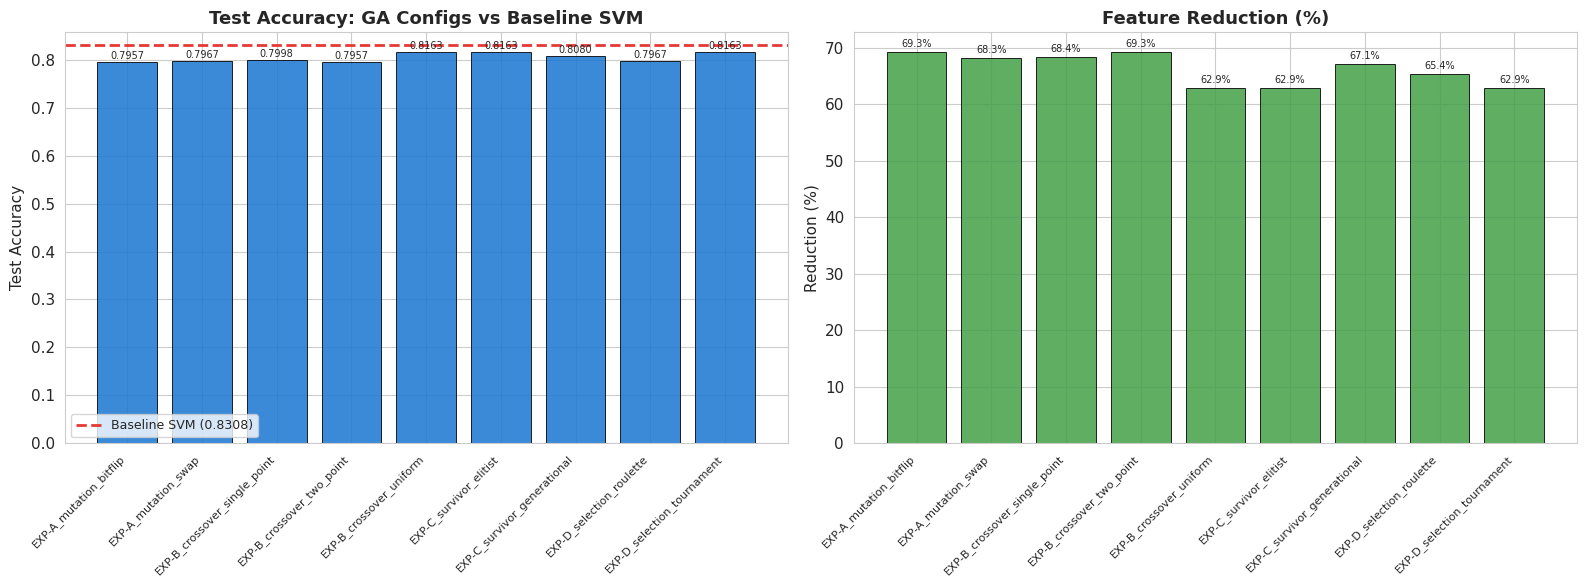

Figure saved -> figures/final_summary.png


In [23]:
# ============================================================
# EVALUATE ON TEST SET
# Take the best individual (highest CV accuracy) from each
# experiment configuration and evaluate it on the held-out
# test set using evaluate_on_test().
# Print test accuracy, feature count, and reduction %.
# Then plot a final summary bar chart vs the baseline.
# ============================================================

print('=== EVALUATE ON TEST: Best Individual per Configuration ===')
print(f'Baseline SVM test accuracy: {baseline_accuracy:.4f}')
print()

test_results = []
for exp_name in sorted(BEST_INDIVIDUALS.keys()):
    best_ind = BEST_INDIVIDUALS[exp_name]
    if best_ind is None:
        print(f'  {exp_name}: no individual stored (skipped)')
        continue
    test_acc, n_sel, red_pct = evaluate_on_test(
        best_ind, X_train, y_train, X_test, y_test
    )
    test_results.append({
        'config'       : exp_name,
        'test_accuracy': test_acc,
        'n_features'   : n_sel,
        'reduction_pct': red_pct,
    })
    print(f'  {exp_name:<40}  test_acc={test_acc:.4f}  '
          f'n_features={n_sel:5d}  reduction={red_pct:.1f}%')

print()

# ── Final summary plots ───────────────────────────────────────
if test_results:
    configs    = [r['config']        for r in test_results]
    test_accs  = [r['test_accuracy'] for r in test_results]
    reductions = [r['reduction_pct'] for r in test_results]
    x = np.arange(len(configs))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Test accuracy vs baseline
    ax = axes[0]
    bars = ax.bar(x, test_accs, color='#1976D2', edgecolor='black',
                  linewidth=0.7, alpha=0.85)
    ax.axhline(baseline_accuracy, color='#E53935', linestyle='--',
               linewidth=2, label=f'Baseline SVM ({baseline_accuracy:.4f})')
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('Test Accuracy: GA Configs vs Baseline SVM', fontweight='bold')
    ax.set_ylabel('Test Accuracy')
    ax.legend(fontsize=9)
    for bar, acc in zip(bars, test_accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{acc:.4f}', ha='center', va='bottom', fontsize=7)

    # Feature reduction
    ax = axes[1]
    bars = ax.bar(x, reductions, color='#43A047', edgecolor='black',
                  linewidth=0.7, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('Feature Reduction (%)', fontweight='bold')
    ax.set_ylabel('Reduction (%)')
    for bar, red in zip(bars, reductions):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{red:.1f}%', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig('figures/final_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved -> figures/final_summary.png')
else:
    print('No test results to plot (no experiments have run yet).')

In [ ]:
# ============================================================
# STRUCTURED RESULTS
# Aggregate all experiment results into master DataFrames.
# ============================================================

# ── df_all_results: one row per run ──────────────────────────
df_all_results = pd.DataFrame(ALL_RESULTS, columns=[
    'experiment_name',
    'mutation_type',
    'crossover_type',
    'survivor_method',
    'selection_method',
    'seed',
    'accuracy',
    'fitness',
    'num_features',
    'runtime_seconds',
])

# ── df_summary: mean ± std per configuration ─────────────────
df_summary = pd.DataFrame(SUMMARY_ROWS)

print('df_all_results shape:', df_all_results.shape)
print()
print('=== ALL RESULTS (individual runs) ===')
print(df_all_results.to_string(index=False))
print()
print('=== SUMMARY (mean ± std per configuration) ===')
if not df_summary.empty:
    summary_display = df_summary[[
        'experiment_name', 'mutation_type', 'crossover_type', 'survivor_method',
        'selection_method',
        'accuracy_mean', 'accuracy_std', 'fitness_mean', 'fitness_std',
        'num_features_mean', 'runtime_mean'
    ]]
    print(summary_display.to_string(index=False))

# Save to CSV
df_all_results.to_csv('ga_all_results.csv', index=False)
df_summary.to_csv('ga_summary.csv', index=False)
print()
print('Saved: ga_all_results.csv, ga_summary.csv')

# end of results section

df_all_results shape: (330, 10)

=== ALL RESULTS (individual runs) ===
             experiment_name mutation_type crossover_type survivor_method selection_method  seed  accuracy  fitness  num_features  runtime_seconds
      EXP-A_mutation_bitflip       bitflip      two_point         elitist       tournament    42  0.687482 0.683020           250       186.997974
      EXP-A_mutation_bitflip       bitflip      two_point         elitist       tournament    43  0.659094 0.662756           213       134.238071
      EXP-A_mutation_bitflip       bitflip      two_point         elitist       tournament    44  0.660384 0.662488           223       132.097831
      EXP-A_mutation_bitflip       bitflip      two_point         elitist       tournament    45  0.669676 0.670137           228       103.838103
      EXP-A_mutation_bitflip       bitflip      two_point         elitist       tournament    46  0.705288 0.701902           230       192.993064
      EXP-A_mutation_bitflip       bitflip     

Best GA config        : EXP-B_crossover_uniform
Test Accuracy         : 0.8163
Features selected     : 260
Feature reduction     : 62.9%
Baseline SVM accuracy : 0.8308

Classification Report (best GA config):
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       321
           1       0.80      0.68      0.74       320
           2       0.87      0.91      0.89       328

    accuracy                           0.82       969
   macro avg       0.82      0.82      0.81       969
weighted avg       0.82      0.82      0.81       969



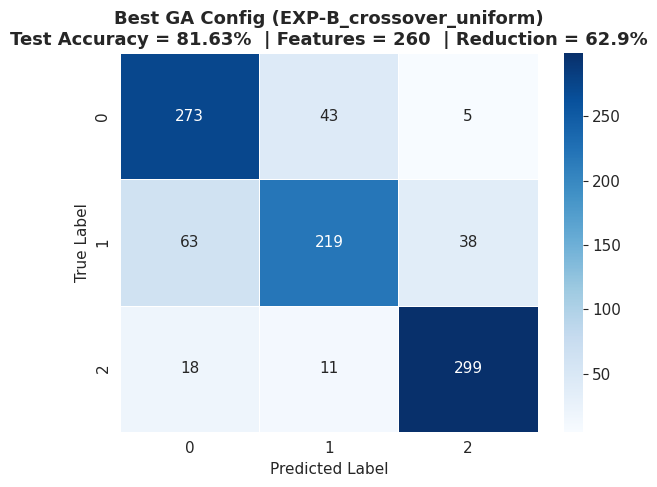

Figure saved → figures/best_ga_confusion_matrix.png


In [24]:
# ============================================================
# Confusion matrix for the best GA configuration on test set
# ============================================================

if test_results:
    # Pick the config with highest test accuracy
    best_result = max(test_results, key=lambda r: r['test_accuracy'])
    best_exp_name = best_result['config']
    best_mask = BEST_INDIVIDUALS[best_exp_name]

    selected_idx = np.where(best_mask == 1)[0]
    svm_best = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
    svm_best.fit(X_train[:, selected_idx], y_train)
    y_pred_best = svm_best.predict(X_test[:, selected_idx])

    print(f'Best GA config        : {best_exp_name}')
    print(f'Test Accuracy         : {best_result["test_accuracy"]:.4f}')
    print(f'Features selected     : {best_result["n_features"]}')
    print(f'Feature reduction     : {best_result["reduction_pct"]:.1f}%')
    print(f'Baseline SVM accuracy : {baseline_accuracy:.4f}')
    print()
    print('Classification Report (best GA config):')
    print(classification_report(y_test, y_pred_best))

    cm_best = confusion_matrix(y_test, y_pred_best)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
    sns.heatmap(
        cm_best, annot=True, fmt='d', cmap='Blues',
        xticklabels=unique_classes, yticklabels=unique_classes,
        linewidths=0.5, ax=ax
    )
    ax.set_title(
        f'Best GA Config ({best_exp_name})\n'
        f'Test Accuracy = {best_result["test_accuracy"]*100:.2f}%  '
        f'| Features = {best_result["n_features"]}  '
        f'| Reduction = {best_result["reduction_pct"]:.1f}%',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.savefig('figures/best_ga_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved → figures/best_ga_confusion_matrix.png')